# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [ ]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?
2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. Why is V_reset lower? It is set lower than V_rest to represent the refractory period (specifically, the after-hyperpolarization phase). After a real neuron spikes, potassium channels stay open for a brief moment, driving the voltage below the resting potential. This makes it harder for the neuron to fire again immediately, preventing it from spiking too fast.

2. What does tau control? In plain English, tau controls how fast the neuron "forgets" its input. It determines the speed at which the voltage leaks back to the resting potential. A small tau means the voltage drops quickly (short memory), while a large tau means it holds onto the charge for longer (long memory).

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [ ]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[200:800] = 1000.0  # Adjusted to 1000 for correct firing rate

# ============ Storage Arrays ============
V = np.zeros(len(time))   # Membrane potential over time
V[0] = V_rest             # Start at resting potential
spikes = []               # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change using the LIF equation
    # dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
    dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )

    # TODO 2: Update the membrane potential
    # V at next time step = V at current step + dV
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    # If V[t+1] >= V_thresh:
    #   - Append time[t+1] to the spikes list
    #   - Reset V[t+1] to V_reset
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 18 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

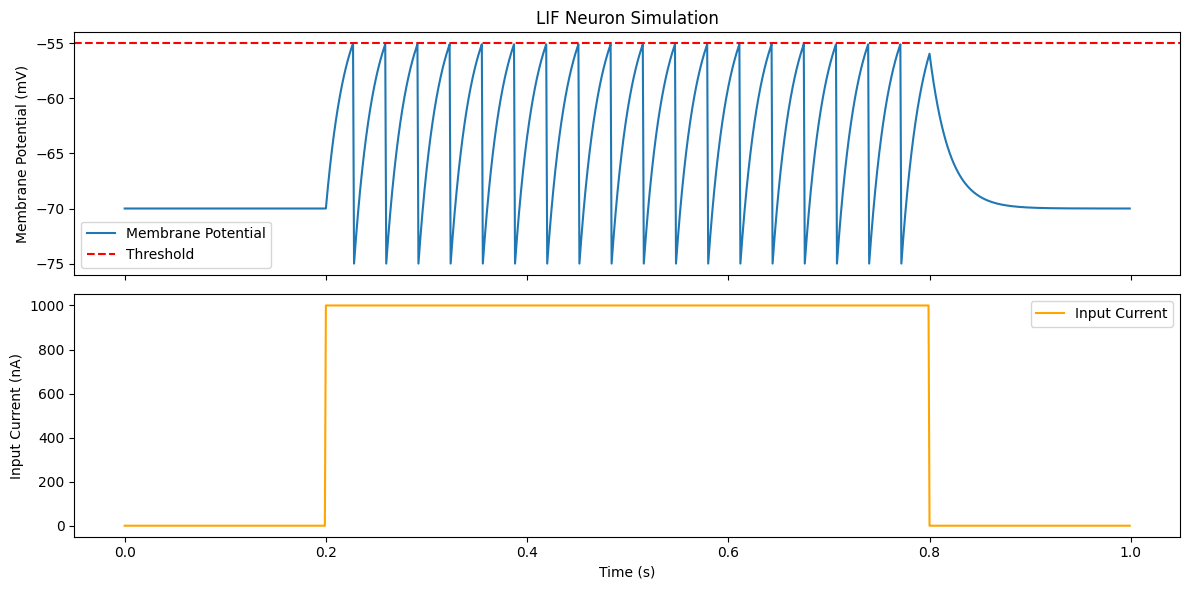

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
# - Plot V over time
# - Add a horizontal dashed line at V_thresh
#   Hint: ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, color='orange', label='Input Current')
ax2.legend()

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. It curves. The membrane potential rises in an exponential curve, not a straight line. This is because as the voltage gets higher (further from rest), the "leak" term in the equation ($$ -(V - V_{rest})/\tau $$) gets larger, fighting against the input current more and more. It's like filling a leaky bucket—it fills slower as the water level rises and pressure increases.


2. It decays back to rest. Once the input current $$ I $$ becomes zero, the only term left in the equation is the leak. The voltage exponentially decays back to $$ V_{rest} $$ (-70 mV) because there is no longer any force pushing it up, only the leak pulling it down.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*

Realistic: The plot accurately shows the "leaky integrator" behavior—voltage rises exponentially as charge accumulates and decays exponentially when input stops. The concept of a firing threshold and a refractory reset (dropping below rest) is also biologically grounded.

Overly Simplified: The "spike" itself is fake; it's just a manual reset line, missing the actual shape of an action potential (the rise and fall driven by sodium and potassium channels). Also, the model treats the neuron as a single point, ignoring dendrites and the complex spatial structure of real neurons.




---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [ ]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # If random < value → spike (1), otherwise no spike (0)
        # Hint: np.random.rand(num_neurons) gives an array of random numbers
        # Hint: (random_array < values) gives True/False, use .astype(float)
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

**Test your function:**

In [ ]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [ ]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # Higher values should spike at EARLIER time steps
            # spike_time = int((1 - values[i]) * (num_steps - 1))
            # This maps value=1.0 → time=0 and value≈0 → time≈num_steps
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

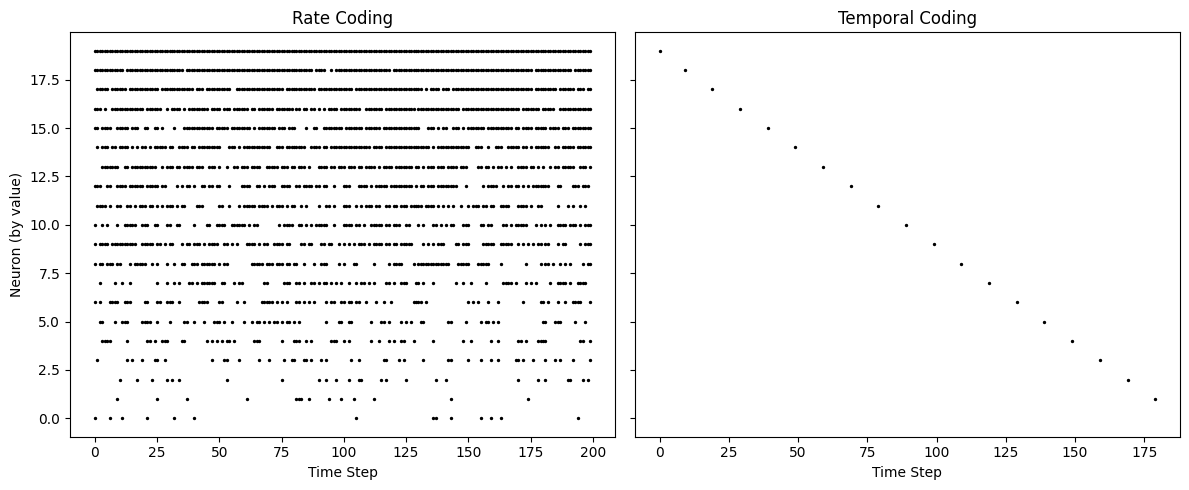

In [ ]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Rate Coding Raster
# np.where returns (row_indices, col_indices) -> (time_step, neuron_index)
rows, cols = np.where(rate_spks == 1)
ax1.scatter(rows, cols, s=2, color='black')
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# Temporal Coding Raster
rows, cols = np.where(temp_spks == 1)
ax2.scatter(rows, cols, s=2, color='black')
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. What is lost/preserved in rate coding?

    a. Lost: The precise timing of the signal. Since we average spikes over a time window, we lose track of exactly when a stimulus changed.

    b. Preserved: The intensity or strength of the signal (represented by the frequency).


2. Why is temporal coding faster? It allows a downstream neuron to respond to the very first spike. In rate coding, the neuron has to wait for a certain time window to pass to "count" the spikes and estimate the rate. Temporal coding sends the information immediately.

2. Real-world example where timing matters: Sound Localization. To figure out where a sound is coming from, your brain measures the tiny time difference (microseconds) between the sound arriving at your left ear versus your right ear. If it relied only on firing rate (volume/pitch), it wouldn't be able to pinpoint the location so precisely.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*

React quickly: Temporal coding is better because the information is contained in the first spike, allowing for an immediate response without waiting to count spikes over time.

Precise measurements: Rate coding is often better for representing graded intensities (like muscle force or brightness) because it averages activity over time, making it more robust to random noise.

Why both? The brain faces a trade-off. It needs temporal coding for split-second tasks (like pinpointing a sound) and rate coding for stable, sustained tasks (like holding a cup). Using both allows it to be both fast and reliable depending on the context.



---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [ ]:
# Network parameters
N = 5  # Number of neurons
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i, j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 10000.0   # Neuron 0 → 2 (excitatory) - Stronger
weights[1, 3] = 10000.0   # Neuron 1 → 3 (excitatory) - Stronger
weights[2, 4] = 10000.0   # Neuron 2 → 4 (excitatory) - Stronger
weights[3, 4] = 10000.0   # Neuron 3 → 4 (excitatory) - Stronger

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 3000.0   # Neuron 0 gets current - Higher rate
I_ext[150:350, 1] = 3000.0   # Neuron 1 gets current - Higher rate

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]  # Spike times per neuron
just_spiked = np.zeros(N, dtype=bool)  # Track spikes at current step

# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked[:] = False

    for n in range(N):
        # TODO 9: Calculate total input current for neuron n
        I_syn = 0
        for j in range(N):
            # Check if neuron j spiked at time step t
            if len(spike_log[j]) > 0 and abs(spike_log[j][-1] - time_net[t]) < 1e-6:
                I_syn += weights[j, n]

        I_total = I_ext[t, n] + I_syn

        # TODO 10: Update membrane potential (same LIF equation as Part A)
        dV = dt * ( -(V_net[t, n] - V_rest) / tau + I_total / C )
        V_net[t+1, n] = V_net[t, n] + dV

        # TODO 11: Check for spike, reset, and record
        if V_net[t+1, n] >= V_thresh:
            V_net[t+1, n] = V_reset
            spike_log[n].append(time_net[t+1])
            just_spiked[n] = True

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 37 spikes
Neuron 1: 25 spikes
Neuron 2: 12 spikes
Neuron 3: 8 spikes
Neuron 4: 8 spikes


> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

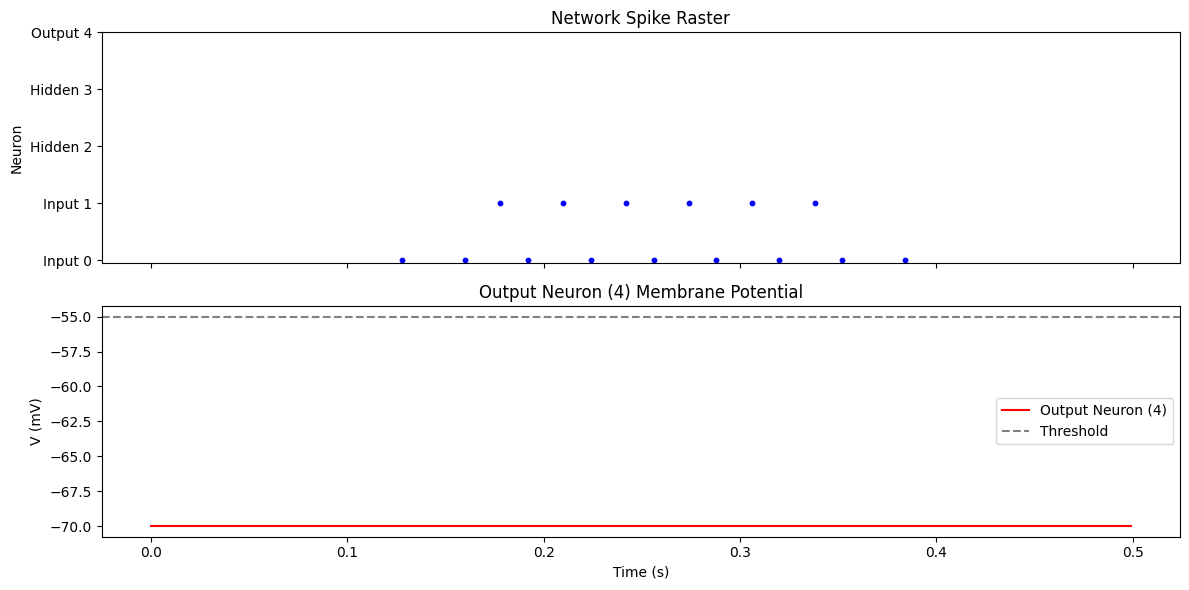

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
# For each neuron n, plot its spike times as dots at y = n
# Use different colors: blue for input (0,1), green for hidden (2,3), red for output (4)
# Hint: ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color='blue')
colors = ['blue', 'blue', 'green', 'green', 'red']
for n in range(N):
    if len(spike_log[n]) > 0:
        ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color=colors[n])

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron (4) membrane potential
ax2.plot(time_net, V_net[:, 4], color='red', label='Output Neuron (4)')
ax2.axhline(y=V_thresh, color='gray', linestyle='--', label='Threshold')
ax2.legend()

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No, it fires at a lower rate. (Input: ~37 spikes vs. Output: ~8 spikes). This is because the neuron "leaks" voltage over time; it takes multiple incoming spikes arriving close together (temporal summation) to push the downstream neuron over the threshold. Some information is lost in transmission.

2. Synaptic weights determine the signal strength (how much voltage is added per spike). Doubling them would make the downstream neurons fire much more frequently (potentially causing a runaway "epileptic" effect). Halving them would likely stop the signal entirely, as the voltage wouldn't reach the threshold before leaking away (as we saw earlier when you got 0 spikes).

3. It would suppress the output. A negative weight is inhibitory, meaning it subtracts from the membrane potential. If weights[3, 4] were negative, every time Neuron 3 fired, it would push Neuron 4 further away from the threshold, counteracting the excitation from Neuron 2 and reducing Neuron 4's firing rate.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment 1:
**Parameter changed:**  I changed V_thresh to -50 mV (harder) and -60 mV (easier).

**Expected result:**  Higher thresholds should stop firing; lower thresholds should increase firing.

In [ ]:
# Experiment 1: Threshold Sensitivity
thresholds = [-50.0, -60.0]

for v_th in thresholds:
    # Reset variables
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    # Run simulation
    for t in range(len(time) - 1):
        dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
        V[t+1] = V[t] + dV

        if V[t+1] >= v_th:
            spikes.append(time[t+1])
            V[t+1] = V_reset

    print(f'Threshold {v_th} mV -> {len(spikes)} spikes')

Threshold -50.0 mV -> 0 spikes
Threshold -60.0 mV -> 33 spikes


**What happened:**  -50 mV resulted in silence (0 spikes), while -60 mV caused rapid firing (33 spikes).

**Why it makes sense:**  It's all about the gap between the resting potential and the threshold. A larger gap (higher threshold) requires more input current to cross. Since the current stayed the same, raising the bar made it impossible to spike, while lowering it made it easy.

### Experiment Experiment 3: Ramp Input

**Parameter changed:**  I_input to a linear ramp (0 to 3000 nA).

**Expected result:**  The firing rate should increased over time (spikes got closer together).

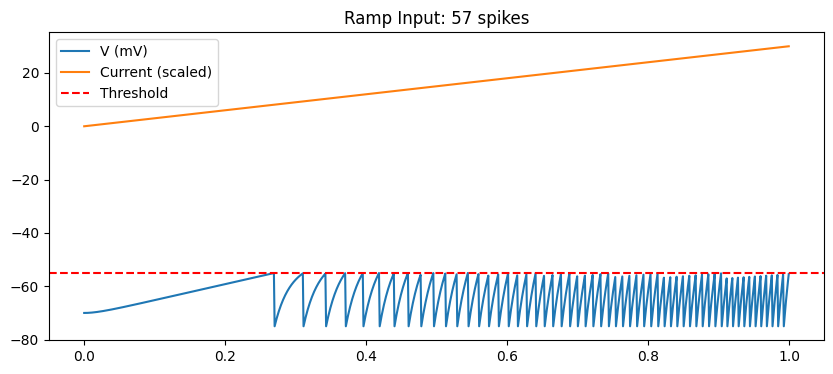

In [ ]:
# Experiment 3: Ramp Input
I_ramp = np.linspace(0, 3000, len(time))
V_ramp = np.zeros(len(time))
V_ramp[0] = V_rest
spikes_ramp = []

for t in range(len(time) - 1):
    dV = dt * ( -(V_ramp[t] - V_rest) / tau + I_ramp[t] / C )
    V_ramp[t+1] = V_ramp[t] + dV

    if V_ramp[t+1] >= V_thresh:
        spikes_ramp.append(time[t+1])
        V_ramp[t+1] = V_reset

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time, V_ramp, label='V (mV)')
plt.plot(time, I_ramp/100, label='Current (scaled)') # Scaled for visibility
plt.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
plt.title(f'Ramp Input: {len(spikes_ramp)} spikes')
plt.legend()
plt.show()

**What happened:**  The firing rate increased over time (spikes got closer together).

**Why it makes sense:**  Higher current charges the membrane faster, so the neuron reaches the threshold quicker after each reset.


### Experiment 5: Inhibition

**Parameter changed:**  

**Expected result:**  

In [ ]:
# Experiment 5: Inhibition
weights_inhib = weights.copy()
weights_inhib[3, 4] = -10000.0  # Strong inhibition from 3 -> 4

# Reset network storage
V_net_exp = np.full((steps, N), V_rest)
spike_log_exp = [[] for _ in range(N)]

# Run network sim
for t in range(steps - 1):
    for n in range(N):
        I_syn = 0
        for j in range(N):
            if len(spike_log_exp[j]) > 0 and abs(spike_log_exp[j][-1] - time_net[t]) < 1e-6:
                I_syn += weights_inhib[j, n]

        I_total = I_ext[t, n] + I_syn
        dV = dt * ( -(V_net_exp[t, n] - V_rest) / tau + I_total / C )
        V_net_exp[t+1, n] = V_net_exp[t, n] + dV

        if V_net_exp[t+1, n] >= V_thresh:
            V_net_exp[t+1, n] = V_reset
            spike_log_exp[n].append(time_net[t+1])

print(f'Baseline Output Spikes (Neuron 4): {len(spike_log[4])}')
print(f'Inhibited Output Spikes (Neuron 4): {len(spike_log_exp[4])}')

Baseline Output Spikes (Neuron 4): 8
Inhibited Output Spikes (Neuron 4): 0


**What happened:**  Neuron 4 went from ~8 spikes to 0 spikes.

**Why it makes sense:**  The inhibitory input from Neuron 3 subtracted from Neuron 4's voltage, preventing it from reaching the threshold despite the excitation from Neuron 2.


---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*

Changing the membrane time constant ($\tau$) fundamentally alters how a neuron processes incoming information. A larger $\tau$ means the voltage leaks away slowly, allowing the neuron to act as an integrator that sums up inputs over a longer window of time. Conversely, a smaller $\tau$ causes the voltage to decay rapidly, forcing the neuron to act as a coincidence detector that only fires if inputs arrive almost simultaneously. Biologically, this parameter represents the physical properties of the cell membrane, specifically its resistance and capacitance, which vary across different types of neurons in the brain to suit their specific computational roles.



### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:*

Comparing the two, temporal coding preserves the precise timing of the signal, which is critical for fast reactions and systems like sound localization where the exact arrival time matters. Rate coding, on the other hand, preserves the intensity or "weight" of the signal through frequency, which is more robust to noise but slower to decode (since it requires integration time). The brain likely uses both strategies in different circuits to balance the need for speed (temporal) with the need for reliability and graded signaling (rate).

### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:*

In the mini SNN, we observed that signals do not automatically propagate through the layers; they can "die out" if the synaptic weights are too weak to overcome the membrane leakage. This mimics real neural circuits, where successful signal transmission depends on synaptic strength and temporal summation. Information only flows if enough pre-synaptic neurons fire effectively to drive the post-synaptic neuron above its threshold.

### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:*

The LIF model captures the essential "all-or-none" spiking mechanism and the integration of inputs over time very well. However, it simplifies the neuron into a single point, missing important biological features like dendritic computation (where the shape of the neuron affects processing), adaptation (changes in firing rate over time), and the complex dynamics of different ion channels and neurotransmitters.




### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:*

I was surprised by how much "tuning" is required to make a spiking network function correctly. Unlike standard artificial neural networks where values just pass through, SNNs require a delicate balance of weights, thresholds, and timing to ensure signals don't fade away or explode into epilepsy-like firing. It highlights the incredible homeostatic capability of the biological brain to self-tune these parameters.


---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.